### 1.传染病模型 (SI模型) $\frac{di}{dt} \sim i$

$\frac{di}{dt} = ki(1 - i), i(0) = i_0$ <br>

其中 <br>
$i(t)$是第t天病人在总人数中所占的比例。 <br>
$λ$是每个病人每天有效接触的平均人数（日接触率）。 <br>
$i_0$是初始时刻（t=0）病人的比例。 <br>

#### 实验要求：

取k=0.1，画出 的曲线图，求i为何值时 达到最大值，并在曲线图上标注。 <br>

root只有一个,故该点为极大值点也为最大值点,当i = 0.500000000000000,di/dt = 0.0250000000000000


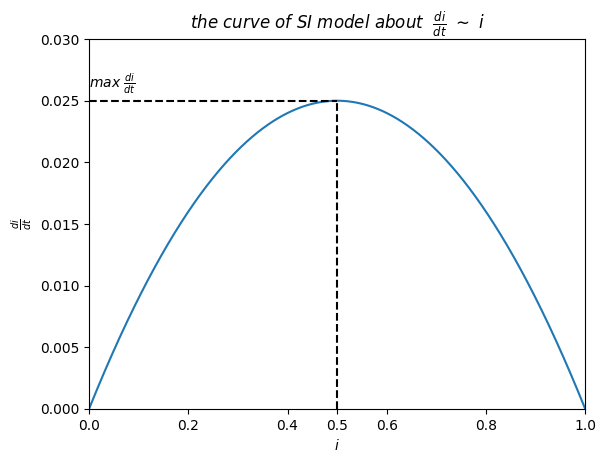

In [1]:


from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

k = 0.1
f: Callable[[float],float] = lambda i: k * i * (1 - i)

x = [i for i in np.linspace(0,1,1000)]
y = [f(i) for i in x]

i = sp.symbols('i')

g = k * i * (1 - i)

root = sp.solve(sp.Eq(g.diff(i),0),i)
print(f"root只有一个,故该点为极大值点也为最大值点,当i = {root[0]},di/dt = { g.subs(i,root[0]) }")

fig,ax = plt.subplots()
ax.set_title(r'$the\ curve\ of\ SI\ model\ about\ \ \frac{di}{dt}\ \sim\ i$')
ax.set_xlabel(r'$i$')
ax.set_ylabel(r'$\frac{di}{dt}$')
ax.set_xlim(0,1)
ax.set_xticks([0.,0.2,0.4,0.5,0.6,0.8,1.0])
ax.set_ylim(0,0.03)
ax.set_yticks([0.,0.005,0.01,0.015,0.02,0.025,0.03])
ax.plot(x,y)
ax.plot([0.5,0.5],[0,f(0.5)],linestyle = '--',color = 'black')
ax.plot([0,0.5],[f(0.5),f(0.5)],linestyle = '--',color = 'black')
ax.text(0.0,0.026,r'$max\ \frac{di}{dt}$');
# fig.show()

### 画$i \sim t$曲线图

$\frac{di}{dt} = ki(1 - i), i(0) = i_0$ <br>

#### 实验要求
求出微分方程的解析解i(t)，画出如下所示的i~t曲线（i(0)=0.15, k=0.2, t=0~30）。试编写一个m文件来实现。（在图形窗口菜单选择Edit/Copy Figure，复制图形）


解析解 Eq(i(t), -1.0/(C1*exp(-0.2*t) - 1.0))


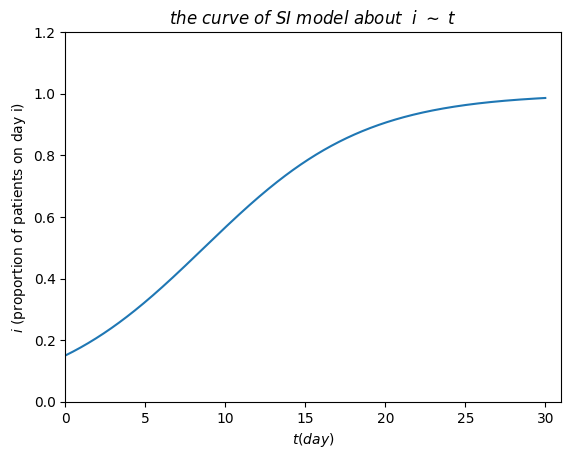

In [3]:


from typing import Callable,List
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

k = 0.2
i_0 = 0.15

t = sp.symbols('t')
i = sp.Function('i')(t)

ode = sp.Eq(i.diff(t),k * i * (1 - i))

res = sp.dsolve(ode,i,ics = { i.subs(t,0): i_0 })
print(f"解析解 {sp.dsolve(ode,i)}")
f = sp.lambdify(t,res.rhs)

x = np.linspace(0,30,1000)
y = np.array([f(t) for t in x])

fig,ax = plt.subplots()
ax.set_title(r'$the\ curve\ of\ SI\ model\ about\ \ i\ \sim\ t$')
ax.set_xlabel(r'$t (day)$')
ax.set_ylabel(r'$i$ (proportion of patients on day i)')
ax.set_xlim(0,31)
ax.set_ylim(0.,1.2)
ax.plot(x,y);
# fig.show()

### SIS模型 $\frac{di}{dt} \sim t$

$\frac{di}{dt} = -\lambda i[i - \left( 1 - \frac{1}{\sigma} \right)], i(0) = i_0$

其中， <br>
i(t)是第t天病人在总人数中所占的比例。 <br>
λ是每个病人每天有效接触的平均人数（日接触率）。 <br>
i0是初始时刻（t=0）病人的比例。 <br>
σ是整个传染期内每个病人有效接触的平均人数（接触数）。 <br>

#### 实验要求
取λ=0.1，σ=1.5，画出如下所示的 曲线图。


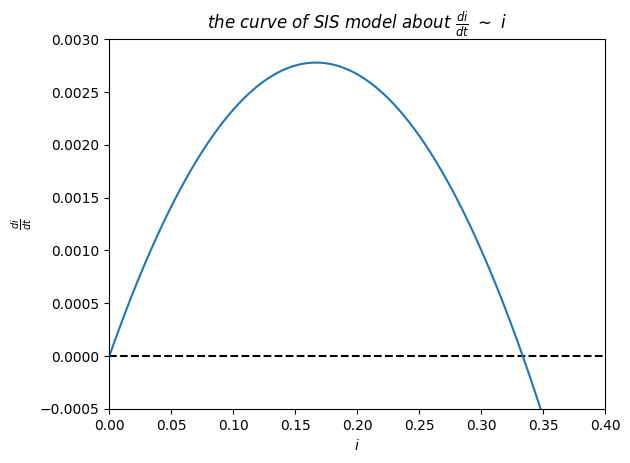

In [10]:

import numpy as np
import matplotlib.pyplot as plt

lb = 0.1
sigma = 1.5

f = lambda i: -lb * i * (i - (1 - 1 / sigma))

x = np.linspace(0,0.4,1000)
y = np.array([f(v) for v in x])

fig,ax = plt.subplots()
ax.set_title(r'$the\ curve\ of\ SIS\ model\ about\ \frac{di}{dt}\ \sim \ i$')
ax.set_xlabel(r'$i$')
ax.set_ylabel(r'$\frac{di}{dt}$')
ax.axhline(0,linestyle = '--',color = 'black')
ax.set_xlim(0,0.4)
ax.set_ylim(-0.0005,0.003)
ax.plot(x,y);
# fig.show()


### 画 $i \sim t$

方程如上 不在给出

解析解为 Eq(i(t), -(5.55111512312578e-17*exp(0.133333333333333*C1 - 0.133333333333333*t) + 0.666666666666667)/(exp(0.133333333333333*C1 - 0.133333333333333*t) - 1))


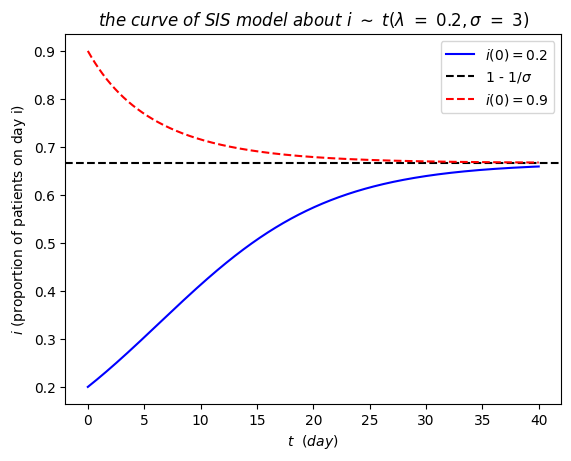

In [8]:


import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

lb = 0.2
sigma = 3
i_0 = 0.2     # 后续调为0.2和0.9
i_1 = 0.9

t = sp.symbols('t')
i = sp.Function('i')(t)

ode = sp.Eq(i.diff(t),-lb * i * (i - (1 - 1 / sigma)))

res = sp.dsolve(ode,i)
print(f'解析解为 {res}')

C1 = sp.symbols('C1')

C1_v = sp.solve(sp.Eq(res.rhs.subs(t,0),i_0),C1)

f1 = sp.lambdify(t,res.rhs.subs(C1,C1_v[0]))
f2 = sp.lambdify(t,res.rhs.subs(C1,sp.solve(sp.Eq(res.rhs.subs(t,0),i_1),C1)[0]))

x = np.linspace(0,40,1000)
y1 = np.array([f1(t) for t in x])
y2 = np.array([f2(t) for t in x])

fig,ax = plt.subplots()
ax.set_title(r'$the\ curve\ of\ SIS\ model\ about\ i\ \sim\ t(\lambda\ =\ 0.2,\sigma\ =\ 3)$')
ax.set_xlabel(r'$t\ \ (day)$')
ax.set_ylabel(r'$i$ (proportion of patients on day i)')
ax.plot(x,y1,color = 'blue',label = r'$i(0)=0.2$')
ax.axhline(1 - 1 / sigma,color = 'black',linestyle='--',label = r'1 - 1/$\sigma$')
ax.plot(x,y2,color = 'red',linestyle='--',label = r'$i(0)=0.9$')
ax.legend();

# fig.show()